## Install dependencies

In [ ]:
!pip install -q "transformers==4.38.2" datasets huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 116.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.2 requires transformers<5.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.


In [ ]:
from huggingface_hub import login
from getpass import getpass
import os

# Hugging Face token with access to meta-llama/Llama-3.2-3B-Instruct
if not os.environ.get("HF_TOKEN"):
    os.environ["HF_TOKEN"] = getpass("Paste your Hugging Face token: ")

# If the model is private, put your token in the HF_TOKEN env var or call login() manually
hf_token = os.environ.get("HF_TOKEN")
if hf_token:
    login(token=hf_token, add_to_git_credential=False)
else:
    print("HF_TOKEN env var not set. If the repo is private, run login(token='hf_xxx') in a separate cell.")

Paste your Hugging Face token: ··········


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [ ]:
import math
import json
import random
from typing import Dict, List, Tuple

import numpy as np
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# --------- LLaDA config ---------
MODEL_NAME = "GSAI-ML/LLaDA-8B-Instruct"    # change to Base if you want
SEED = 42

# Core diffusion / generation knobs
GEN_LENGTH = 256         # fixed as requested
BLOCK_LENGTH = 32        # keep 32 (8 blocks when gen_length=256)
DIFFUSION_STEPS_LIST = [64, 128, 256]   # sweep over these
BASE_TEMPERATURE = 0.0   # deterministic base answer
SC_TEMPERATURE = 0.7     # stochastic for self-consistency
GR_TEMPERATURE = 0.0     # guided retry is deterministic by default

# Repairability settings
NUM_SC_SAMPLES = 5           # how many samples for self-consistency
MAX_GSM8K_EXAMPLES = 200     # you can bump this to a few hundred
GSM8K_FEW_SHOT = 0           # number of few-shot examples (0 = pure zero-shot)

# Fix random seeds for reproducibility
def set_global_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_global_seed(SEED)

Using device: cuda


In [ ]:
# Diffusion-style generate for LLaDA (masked sampling)

import torch
import torch.nn.functional as F
from tqdm import tqdm
import torch.distributed as dist

def gumbel_max_sample(logits: torch.Tensor, temperature: float) -> torch.Tensor:
    """
    Correct Gumbel-Max sampling:
      argmax( (logits / T) + Gumbel(0,1) )
    If temperature == 0, falls back to greedy argmax(logits).
    """
    if temperature is None or temperature <= 0.0:
        return logits.argmax(dim=-1)

    logits = logits.float() / max(1e-6, float(temperature))
    # clamp to avoid log(0)
    u = torch.rand_like(logits, dtype=torch.float32).clamp_(1e-6, 1.0 - 1e-6)
    g = -torch.log(-torch.log(u))
    return (logits + g).argmax(dim=-1)

def apply_top_k_top_p(logits: torch.Tensor, top_k: int = 0, top_p: float = 0.0) -> torch.Tensor:
    """
    Filter logits with top-k and/or top-p. Returns filtered logits (float32).
    """
    logits = logits.float()
    if top_k and top_k > 0:
        v, _ = torch.topk(logits, top_k, dim=-1)
        cut = v[..., -1, None]
        logits = torch.where(logits < cut, torch.full_like(logits, -float("inf")), logits)

    if top_p and top_p > 0.0:
        sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
        probs = torch.softmax(sorted_logits, dim=-1)
        cumprobs = probs.cumsum(dim=-1)
        cutoff = cumprobs > top_p
        cutoff[..., 0] = False
        sorted_logits[cutoff] = -float("inf")
        # scatter back
        logits = torch.full_like(logits, -float("inf"))
        logits.scatter_(dim=-1, index=sorted_idx, src=sorted_logits)

    return logits

def repetition_penalize_logits(logits: torch.Tensor, seq: torch.Tensor, penalty: float = 1.0) -> torch.Tensor:
    """
    Very light repetition penalty: >1.0 discourages re-using tokens already in seq.
    Implemented by dividing logits of seen tokens by penalty.
    """
    if penalty is None or penalty <= 1.0:
        return logits
    logits = logits.float()
    B, T = seq.shape
    V = logits.size(-1)
    # Build a mask of tokens present in each sequence (approx; cost O(B*T))
    seen = torch.zeros((B, V), device=seq.device, dtype=torch.bool)
    seen.scatter_(1, seq, True)
    # Normalize by penalty for seen tokens
    seen = seen.unsqueeze(1).expand(-1, logits.size(1), -1)  # [B, T, V]
    logits = torch.where(seen, logits / penalty, logits)
    return logits

@torch.no_grad()
def diffusion_generate(
    model,
    prompt_ids: torch.Tensor,
    tokenizer,
    steps: int = 64,
    gen_length: int = 128,
    block_length: int = 32,
    temperature: float = 0.0,
    cfg_scale: float = 0.0,
    remasking: str = "low_confidence",
    mask_id: int = 126336,
    top_k: int = 0,
    top_p: float = 0.0,
    rep_penalty: float = 1.0,
):
    """
    Masked diffusion-style generation (blockwise), from your generate.py:
      - Start with gen window masked with mask_id
      - Iteratively replace most-confident masked tokens
    """
    device_model = next(model.parameters()).device
    prompt_ids = prompt_ids.to(device_model)

    B = prompt_ids.shape[0]
    T_prompt = prompt_ids.shape[1]

    # Work in int64 ids buffer
    x = torch.full((B, T_prompt + gen_length), mask_id, dtype=torch.long, device=device_model)
    x[:, :T_prompt] = prompt_ids.clone()

    prompt_index = x != mask_id
    assert gen_length % block_length == 0
    num_blocks = gen_length // block_length
    steps_per_block = max(1, steps // num_blocks)

    # Main loop
    for b in tqdm(
        range(num_blocks),
        disable=(dist.is_available() and dist.is_initialized() and dist.get_rank() != 0),
        desc=f"Eval (len={gen_length}, steps={steps})",
    ):
        start_idx = T_prompt + b * block_length
        end_idx   = T_prompt + (b + 1) * block_length

        # how many tokens to reveal each inner step per sequence (evenly split)
        block_mask_index = x[:, start_idx:end_idx] == mask_id
        mask_num = block_mask_index.sum(dim=1, keepdim=True)  # [B,1]
        base = mask_num // steps_per_block
        rem  = mask_num %  steps_per_block
        num_transfer_tokens = base.expand(-1, steps_per_block).clone()
        if (rem > 0).any():
            idx = torch.arange(steps_per_block, device=device_model).unsqueeze(0)
            add = (idx < rem).to(num_transfer_tokens.dtype)
            num_transfer_tokens += add

        for i in range(steps_per_block):
            mask_index = x == mask_id  # [B, T_prompt + gen_length]

            # classifier-free guidance (two passes in one forward)
            if cfg_scale and cfg_scale > 0.0:
                un_x = x.clone()
                un_x[prompt_index] = mask_id
                x_ = torch.cat([x, un_x], dim=0)
                outputs = model(x_)
                logits, un_logits = torch.chunk(outputs.logits, 2, dim=0)
                logits = (un_logits + (cfg_scale + 1.0) * (logits - un_logits)).float()
            else:
                outputs = model(x)
                logits = outputs.logits.float()  # [B, T, V]

            # discourage repeats a bit
            logits = repetition_penalize_logits(logits, x, penalty=rep_penalty)

            # (optional) top-k / top-p filtering
            logits = apply_top_k_top_p(logits, top_k=top_k, top_p=top_p)

            # choose token ids
            x0 = gumbel_max_sample(logits, temperature=temperature)  # [B, T]

            # confidence: p(token) at chosen ids
            if remasking == "low_confidence":
                smx = torch.softmax(logits, dim=-1)
                x0_p = torch.gather(smx, dim=-1, index=x0.unsqueeze(-1)).squeeze(-1)  # [B, T]
            elif remasking == "random":
                x0_p = torch.rand_like(x0, dtype=torch.float32)
            else:
                raise NotImplementedError(remasking)

            # do not transfer outside current block
            x0_p[:, end_idx:] = -float("inf")
            # only allow masked positions to be transferred
            x0 = torch.where(mask_index, x0, x)
            conf = torch.where(mask_index, x0_p, torch.full_like(x0_p, -float("inf")))

            # pick the top num_transfer_tokens masked positions per sequence
            for j in range(B):
                k = int(num_transfer_tokens[j, i].item())
                if k <= 0:
                    continue
                _, idxs = torch.topk(conf[j], k=k, dim=-1)
                # update those positions
                x[j, idxs] = x0[j, idxs]

    return x

In [ ]:
# GSM8K helpers and prompts

GSM_SYSTEM_PROMPT = """You are a math expert. You will be given a question to solve. Solve it step by step. Wrap the final answer in a \\boxed{}.
Respond in the following format:
<reasoning>
Your reasoning here
</reasoning>
<answer>
\\boxed{...}
</answer>"""

def load_gsm8k_split(use_test_split: bool = True):
    """
    Returns the GSM8K HF split (openai/gsm8k, 'main').
    """
    ds = load_dataset("openai/gsm8k", "main")
    split = "test" if use_test_split else "train"
    return ds[split]

def sample_hf_dataset(ds, max_examples: int, seed: int = 42):
    """
    Randomly sample up to max_examples from a HF Dataset.
    """
    if max_examples is None or max_examples >= len(ds):
        return ds
    indices = list(range(len(ds)))
    rng = random.Random(seed)
    rng.shuffle(indices)
    indices = indices[:max_examples]
    return ds.select(indices)

def make_gsm8k_few_shot_prompt(num_examples: int, seed: int = 42) -> str:
    """
    Build a few-shot prompt from GSM8K train split, in the same style as gsm8k.py.
    """
    if num_examples <= 0:
        return ""
    train_data = load_dataset("gsm8k", "main", split="train")
    rng = random.Random(seed)
    ex_ids = rng.sample(range(len(train_data)), num_examples)
    formatted = []
    for i in ex_ids:
        ex = train_data[i]
        input_text = ex["question"]
        answer = ex["answer"]
        formatted.append(f"Question: {input_text}\nAnswer:\n{answer}")
    return "\n\n".join(formatted)

def build_gsm8k_prompt(
    tokenizer,
    question: str,
    system_prompt: str,
    few_shot_prompt: str = "",
    add_reasoning: bool = True,
) -> str:
    """
    Mirror your GSM8KDataset.create_prompt:
      - optional few-shot Q/A
      - question
      - wrapped by system prompt
      - add <reasoning> tag to push chain-of-thought style
    """
    if few_shot_prompt:
        prompt = f"{few_shot_prompt}\n\nQuestion: {question}\nAnswer:\n"
    else:
        prompt = question

    messages = [{"role": "user", "content": system_prompt + "\n\n" + prompt}]
    if hasattr(tokenizer, "apply_chat_template"):
        user_input = tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=False,
        )
    else:
        user_input = system_prompt + "\n\n" + prompt

    if add_reasoning:
        return user_input + "<reasoning>"
    else:
        return user_input

In [ ]:
# Numeric correctness helpers

import re as _re

def _extract_last_number(text: str):
    nums = _re.findall(r"-?\d+(?:\.\d+)?", text)
    if not nums:
        return None
    return nums[-1]

def _gold_numeric_for_gsm8k(ex):
    ans_text = ex["answer"]
    m = _re.search(r"####\s*(-?\d+(?:\.\d+)?)", ans_text)
    if m:
        return m.group(1)
    nums = _re.findall(r"-?\d+(?:\.\d+)?", ans_text)
    return nums[-1] if nums else None

def is_model_answer_correct(ds_name: str, ex, model_answer: str) -> bool:
    """
    Very simple correctness check:
      - gsm8k: compare final numeric value
    """
    ds_name = ds_name.lower()
    model_answer = model_answer.strip()
    if ds_name == "gsm8k":
        gold = _gold_numeric_for_gsm8k(ex)
        pred = _extract_last_number(model_answer)
        if gold is None or pred is None:
            return False
        try:
            return float(pred) == float(gold)
        except ValueError:
            return pred == gold

    # default: not supported
    return False

In [ ]:
# Load LLaDA tokenizer & model (diffusion LM)

llada_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)

llada_model = AutoModel.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
)
# Some builds expose set_attn_implementation; if so, you can keep "eager"
if hasattr(llada_model, "set_attn_implementation"):
    llada_model.set_attn_implementation("eager")

llada_model.to(device)
llada_model.eval()

print("Loaded LLaDA model:", MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


...

model-00005-of-00006.safetensors:   0%|          | 0.00/2.92G [00:00<?, ?B/s]

model-00006-of-00006.safetensors:   0%|          | 0.00/2.11G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/128 [00:00<?, ?B/s]

Loaded LLaDA model: GSAI-ML/LLaDA-8B-Instruct


In [ ]:
@torch.no_grad()
def llada_diffusion_generate_answer(
    model,
    tokenizer,
    question: str,
    device: str,
    gen_length: int,
    diffusion_steps: int,
    temperature: float,
    system_prompt: str = GSM_SYSTEM_PROMPT,
    few_shot_prompt: str = "",
    add_reasoning: bool = True,
) -> str:
    """
    Single-shot LLaDA answer using masked diffusion sampler.
    """
    prompt_text = build_gsm8k_prompt(
        tokenizer,
        question=question,
        system_prompt=system_prompt,
        few_shot_prompt=few_shot_prompt,
        add_reasoning=add_reasoning,
    )
    enc = tokenizer(prompt_text, return_tensors="pt")
    input_ids = enc["input_ids"].to(device)

    out_ids = diffusion_generate(
        model,
        input_ids,
        tokenizer,
        steps=diffusion_steps,
        gen_length=gen_length,
        block_length=BLOCK_LENGTH,
        temperature=temperature,
        cfg_scale=0.0,
        remasking="low_confidence",
    )

    # Only decode the generated window, like eval_sft_task2.py :contentReference[oaicite:8]{index=8}
    gen_ids = out_ids[:, -gen_length:]
    text = tokenizer.batch_decode(
        gen_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True,
    )[0]
    return text.strip()

def _majority_vote_by_last_number_or_text(answers: List[str]) -> str:
    """
    Same idea as your self-consistency helper: group by last number, then majority.
    """
    def _key(ans: str):
        nums = _re.findall(r"-?\d+(?:\.\d+)?", ans)
        return nums[-1] if nums else ans.strip().lower()

    key_counts: Dict[str, int] = {}
    for a in answers:
        k = _key(a)
        key_counts[k] = key_counts.get(k, 0) + 1

    best_key = max(key_counts.items(), key=lambda kv: kv[1])[0]
    for a in answers:
        if _key(a) == best_key:
            return a
    return answers[0]

@torch.no_grad()
def llada_diffusion_self_consistency_answer(
    model,
    tokenizer,
    question: str,
    device: str,
    num_samples: int,
    gen_length: int,
    diffusion_steps: int,
    temperature: float,
    system_prompt: str = GSM_SYSTEM_PROMPT,
    few_shot_prompt: str = "",
    add_reasoning: bool = True,
) -> str:
    """
    Self-consistency: sample multiple diffusion generations and majority-vote
    by final numeric answer (or last token if no number).
    """
    answers: List[str] = []
    for _ in range(num_samples):
        ans = llada_diffusion_generate_answer(
            model=model,
            tokenizer=tokenizer,
            question=question,
            device=device,
            gen_length=gen_length,
            diffusion_steps=diffusion_steps,
            temperature=temperature,
            system_prompt=system_prompt,
            few_shot_prompt=few_shot_prompt,
            add_reasoning=add_reasoning,
        )
        answers.append(ans)
    return _majority_vote_by_last_number_or_text(answers)

def _build_guided_retry_prompt(
    tokenizer,
    question: str,
    base_answer: str,
    system_prompt: str = GSM_SYSTEM_PROMPT,
) -> str:
    """
    Guided retry: tell the model its previous answer might be wrong and ask
    it to re-check step by step, in the same GSM format.
    """
    content = (
        system_prompt
        + "\n\n"
        "We previously tried to solve the following math problem.\n"
        f"Question:\n{question}\n\n"
        "A previous attempt produced the following answer (which may be incorrect):\n"
        f"{base_answer}\n\n"
        "Please carefully re-check your reasoning step by step, fix any mistakes, "
        "and then give a final answer clearly in the same format as before."
    )
    messages = [{"role": "user", "content": content}]
    if hasattr(tokenizer, "apply_chat_template"):
        prompt = tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=False,
        )
    else:
        prompt = content + "\nAnswer:\n"
    # We still want the model to emit <reasoning>...</reasoning> <answer>...
    return prompt + "<reasoning>"

@torch.no_grad()
def llada_diffusion_guided_retry_answer(
    model,
    tokenizer,
    question: str,
    base_answer: str,
    device: str,
    gen_length: int,
    diffusion_steps: int,
    temperature: float,
    system_prompt: str = GSM_SYSTEM_PROMPT,
) -> str:
    """
    Guided refinement via diffusion sampling.
    """
    prompt_text = _build_guided_retry_prompt(
        tokenizer=tokenizer,
        question=question,
        base_answer=base_answer,
        system_prompt=system_prompt,
    )
    enc = tokenizer(prompt_text, return_tensors="pt")
    input_ids = enc["input_ids"].to(device)

    out_ids = diffusion_generate(
        model,
        input_ids,
        tokenizer,
        steps=diffusion_steps,
        gen_length=gen_length,
        block_length=BLOCK_LENGTH,
        temperature=temperature,
        cfg_scale=0.0,
        remasking="low_confidence",
    )
    gen_ids = out_ids[:, -gen_length:]
    text = tokenizer.batch_decode(
        gen_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True,
    )[0]
    return text.strip()

In [ ]:
@torch.no_grad()
def llada_diffusion_generate_answer(
    model,
    tokenizer,
    question: str,
    device: str,
    gen_length: int,
    diffusion_steps: int,
    temperature: float,
    system_prompt: str = GSM_SYSTEM_PROMPT,
    few_shot_prompt: str = "",
    add_reasoning: bool = True,
) -> str:
    """
    Single-shot LLaDA answer using masked diffusion sampler.
    """
    prompt_text = build_gsm8k_prompt(
        tokenizer,
        question=question,
        system_prompt=system_prompt,
        few_shot_prompt=few_shot_prompt,
        add_reasoning=add_reasoning,
    )
    enc = tokenizer(prompt_text, return_tensors="pt")
    input_ids = enc["input_ids"].to(device)

    out_ids = diffusion_generate(
        model,
        input_ids,
        tokenizer,
        steps=diffusion_steps,
        gen_length=gen_length,
        block_length=BLOCK_LENGTH,
        temperature=temperature,
        cfg_scale=0.0,
        remasking="low_confidence",
    )

    # Only decode the generated window, like eval_sft_task2.py :contentReference[oaicite:8]{index=8}
    gen_ids = out_ids[:, -gen_length:]
    text = tokenizer.batch_decode(
        gen_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True,
    )[0]
    return text.strip()

def _majority_vote_by_last_number_or_text(answers: List[str]) -> str:
    """
    Same idea as your self-consistency helper: group by last number, then majority.
    """
    def _key(ans: str):
        nums = _re.findall(r"-?\d+(?:\.\d+)?", ans)
        return nums[-1] if nums else ans.strip().lower()

    key_counts: Dict[str, int] = {}
    for a in answers:
        k = _key(a)
        key_counts[k] = key_counts.get(k, 0) + 1

    best_key = max(key_counts.items(), key=lambda kv: kv[1])[0]
    for a in answers:
        if _key(a) == best_key:
            return a
    return answers[0]

@torch.no_grad()
def llada_diffusion_self_consistency_answer(
    model,
    tokenizer,
    question: str,
    device: str,
    num_samples: int,
    gen_length: int,
    diffusion_steps: int,
    temperature: float,
    system_prompt: str = GSM_SYSTEM_PROMPT,
    few_shot_prompt: str = "",
    add_reasoning: bool = True,
) -> str:
    """
    Self-consistency: sample multiple diffusion generations and majority-vote
    by final numeric answer (or last token if no number).
    """
    answers: List[str] = []
    for _ in range(num_samples):
        ans = llada_diffusion_generate_answer(
            model=model,
            tokenizer=tokenizer,
            question=question,
            device=device,
            gen_length=gen_length,
            diffusion_steps=diffusion_steps,
            temperature=temperature,
            system_prompt=system_prompt,
            few_shot_prompt=few_shot_prompt,
            add_reasoning=add_reasoning,
        )
        answers.append(ans)
    return _majority_vote_by_last_number_or_text(answers)

def _build_guided_retry_prompt(
    tokenizer,
    question: str,
    base_answer: str,
    system_prompt: str = GSM_SYSTEM_PROMPT,
) -> str:
    """
    Guided retry: tell the model its previous answer might be wrong and ask
    it to re-check step by step, in the same GSM format.
    """
    content = (
        system_prompt
        + "\n\n"
        "We previously tried to solve the following math problem.\n"
        f"Question:\n{question}\n\n"
        "A previous attempt produced the following answer (which may be incorrect):\n"
        f"{base_answer}\n\n"
        "Please carefully re-check your reasoning step by step, fix any mistakes, "
        "and then give a final answer clearly in the same format as before."
    )
    messages = [{"role": "user", "content": content}]
    if hasattr(tokenizer, "apply_chat_template"):
        prompt = tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=False,
        )
    else:
        prompt = content + "\nAnswer:\n"
    # We still want the model to emit <reasoning>...</reasoning> <answer>...
    return prompt + "<reasoning>"

@torch.no_grad()
def llada_diffusion_guided_retry_answer(
    model,
    tokenizer,
    question: str,
    base_answer: str,
    device: str,
    gen_length: int,
    diffusion_steps: int,
    temperature: float,
    system_prompt: str = GSM_SYSTEM_PROMPT,
) -> str:
    """
    Guided refinement via diffusion sampling.
    """
    prompt_text = _build_guided_retry_prompt(
        tokenizer=tokenizer,
        question=question,
        base_answer=base_answer,
        system_prompt=system_prompt,
    )
    enc = tokenizer(prompt_text, return_tensors="pt")
    input_ids = enc["input_ids"].to(device)

    out_ids = diffusion_generate(
        model,
        input_ids,
        tokenizer,
        steps=diffusion_steps,
        gen_length=gen_length,
        block_length=BLOCK_LENGTH,
        temperature=temperature,
        cfg_scale=0.0,
        remasking="low_confidence",
    )
    gen_ids = out_ids[:, -gen_length:]
    text = tokenizer.batch_decode(
        gen_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True,
    )[0]
    return text.strip()

In [ ]:
def run_llada_diffusion_repairability_on_gsm8k(
    model,
    tokenizer,
    ds,
    device: str,
    gen_length: int,
    diffusion_steps: int,
    num_sc_samples: int = 5,
    max_examples: int = None,
    few_shot_examples: int = 0,
    seed: int = 42,
) -> Dict[str, float]:
    """
    Repairability metrics for LLaDA on GSM8K using diffusion sampling.

    We compute:
      - base_accuracy
      - sc_accuracy  (policy: if base wrong, use self-consistency)
      - gr_accuracy  (policy: if base wrong, use guided retry)
      - sc_repair_success_rate (among initially incorrect examples)
      - gr_repair_success_rate (among initially incorrect examples)
    """
    set_global_seed(seed)
    ds = sample_hf_dataset(ds, max_examples, seed=seed)
    n = len(ds)
    print(f"[LLaDA-diffusion] GSM8K repairability run (n={n}, steps={diffusion_steps}).")

    # few-shot prompt (built once)
    few_shot_prompt = make_gsm8k_few_shot_prompt(few_shot_examples, seed=seed) if few_shot_examples > 0 else ""

    base_correct = 0
    sc_correct = 0
    gr_correct = 0
    num_initially_incorrect = 0
    sc_repairs_success = 0
    gr_repairs_success = 0

    for i, ex in enumerate(tqdm(ds, total=n)):
        question = ex["question"]

        # 1) Base deterministic answer
        base_ans = llada_diffusion_generate_answer(
            model=model,
            tokenizer=tokenizer,
            question=question,
            device=device,
            gen_length=gen_length,
            diffusion_steps=diffusion_steps,
            temperature=BASE_TEMPERATURE,
            system_prompt=GSM_SYSTEM_PROMPT,
            few_shot_prompt=few_shot_prompt,
            add_reasoning=True,
        )
        base_is_correct = is_model_answer_correct("gsm8k", ex, base_ans)
        if base_is_correct:
            base_correct += 1
        else:
            num_initially_incorrect += 1

        # 2) Self-consistency (only if base is wrong; policy keeps base if already correct)
        if base_is_correct:
            sc_final_correct = True
        else:
            sc_ans = llada_diffusion_self_consistency_answer(
                model=model,
                tokenizer=tokenizer,
                question=question,
                device=device,
                num_samples=num_sc_samples,
                gen_length=gen_length,
                diffusion_steps=diffusion_steps,
                temperature=SC_TEMPERATURE,
                system_prompt=GSM_SYSTEM_PROMPT,
                few_shot_prompt=few_shot_prompt,
                add_reasoning=True,
            )
            sc_final_correct = is_model_answer_correct("gsm8k", ex, sc_ans)
            if sc_final_correct:
                sc_repairs_success += 1

        if sc_final_correct:
            sc_correct += 1

        # 3) Guided retry (again, only if base is wrong; policy keeps base if already correct)
        if base_is_correct:
            gr_final_correct = True
        else:
            gr_ans = llada_diffusion_guided_retry_answer(
                model=model,
                tokenizer=tokenizer,
                question=question,
                base_answer=base_ans,
                device=device,
                gen_length=gen_length,
                diffusion_steps=diffusion_steps,
                temperature=GR_TEMPERATURE,
                system_prompt=GSM_SYSTEM_PROMPT,
            )
            gr_final_correct = is_model_answer_correct("gsm8k", ex, gr_ans)
            if gr_final_correct:
                gr_repairs_success += 1

        if gr_final_correct:
            gr_correct += 1

    base_accuracy = base_correct / max(n, 1)
    sc_accuracy = sc_correct / max(n, 1)
    gr_accuracy = gr_correct / max(n, 1)

    if num_initially_incorrect > 0:
        sc_rsr = sc_repairs_success / num_initially_incorrect
        gr_rsr = gr_repairs_success / num_initially_incorrect
    else:
        sc_rsr = 0.0
        gr_rsr = 0.0

    metrics = {
        "num_examples": n,
        "base_accuracy": base_accuracy,
        "sc_accuracy": sc_accuracy,
        "gr_accuracy": gr_accuracy,
        "num_initially_incorrect": num_initially_incorrect,
        "sc_repair_successes": sc_repairs_success,
        "gr_repair_successes": gr_repairs_success,
        "sc_repair_success_rate": sc_rsr,
        "gr_repair_success_rate": gr_rsr,
    }
    return metrics

In [ ]:
# Load GSM8K test split
gsm8k_test = load_gsm8k_split(use_test_split=True)

llada_diffusion_results_by_steps: Dict[int, Dict[str, float]] = {}

for steps in [16, 32, 256]:
    metrics = run_llada_diffusion_repairability_on_gsm8k(
        model=llada_model,
        tokenizer=llada_tokenizer,
        ds=gsm8k_test,
        device=device,
        gen_length=GEN_LENGTH,
        diffusion_steps=steps,
        num_sc_samples=NUM_SC_SAMPLES,
        max_examples=MAX_GSM8K_EXAMPLES,
        few_shot_examples=GSM8K_FEW_SHOT,
        seed=SEED,
    )
    llada_diffusion_results_by_steps[steps] = metrics
    print(f"\n=== Diffusion steps = {steps} ===")
    print(json.dumps(metrics, indent=2))

[LLaDA-diffusion] GSM8K repairability run (n=200, steps=16).


Streaming output truncated to the last 5000 lines.

Eval (len=256, steps=16): 100%|██████████| 8/8 [00:00<00:00, 10.04it/s]

Eval (len=256, steps=16): 100%|██████████| 8/8 [00:00<00:00, 10.48it/s]

Eval (len=256, steps=16): 100%|██████████| 8/8 [00:00<00:00, 10.13it/s]

Eval (len=256, steps=16): 100%|██████████| 8/8 [00:00<00:00, 10.05it/s]

Eval (len=256, steps=16): 100%|██████████| 8/8 [00:00<00:00,  9.99it/s]

Eval (len=256, steps=16): 100%|██████████| 8/8 [00:00<00:00, 10.09it/s]

Eval (len=256, steps=16): 100%|██████████| 8/8 [00:00<00:00, 10.14it/s]

Eval (len=256, steps=16): 100%|██████████| 8/8 [00:00<00:00, 10.50it/s]

Eval (len=256, steps=16): 100%|██████████| 8/8 [00:00<00:00, 10.09it/s]

Eval (len=256, steps=16): 100%|██████████| 8/8 [00:00<00:00, 10.07it/s]

Eval (len=256, steps=16): 100%|██████████| 8/8 [00:00<00:00, 10.13it/s]

Eval (len=256, steps=16): 100%|██████████| 8/8 [00:00<00:00, 10.09it/s]

Eval (len=256, steps=16): 100%|██████████| 8/8 [00:00<00:00, 10.14it/s]



=== Diffusion steps = 16 ===
{
  "num_examples": 200,
  "base_accuracy": 0.355,
  "sc_accuracy": 0.495,
  "gr_accuracy": 0.46,
  "num_initially_incorrect": 129,
  "sc_repair_successes": 28,
  "gr_repair_successes": 21,
  "sc_repair_success_rate": 0.21705426356589147,
  "gr_repair_success_rate": 0.16279069767441862
}
[LLaDA-diffusion] GSM8K repairability run (n=200, steps=32).


Streaming output truncated to the last 5000 lines.
Eval (len=256, steps=32): 100%|██████████| 8/8 [00:01<00:00,  4.84it/s]

Eval (len=256, steps=32): 100%|██████████| 8/8 [00:01<00:00,  4.84it/s]

Eval (len=256, steps=32): 100%|██████████| 8/8 [00:01<00:00,  4.84it/s]

Eval (len=256, steps=32): 100%|██████████| 8/8 [00:01<00:00,  4.83it/s]

Eval (len=256, steps=32): 100%|██████████| 8/8 [00:01<00:00,  4.82it/s]

Eval (len=256, steps=32): 100%|██████████| 8/8 [00:01<00:00,  5.17it/s]

Eval (len=256, steps=32): 100%|██████████| 8/8 [00:01<00:00,  4.96it/s]

Eval (len=256, steps=32): 100%|██████████| 8/8 [00:01<00:00,  4.96it/s]

Eval (len=256, steps=32): 100%|██████████| 8/8 [00:01<00:00,  4.98it/s]

Eval (len=256, steps=32): 100%|██████████| 8/8 [00:01<00:00,  4.96it/s]

Eval (len=256, steps=32): 100%|██████████| 8/8 [00:01<00:00,  4.94it/s]

Eval (len=256, steps=32): 100%|██████████| 8/8 [00:01<00:00,  5.81it/s]

Eval (len=256, steps=32): 100%|██████████| 8/8 [00:01<00:00,  5.61it/s]




=== Diffusion steps = 32 ===
{
  "num_examples": 200,
  "base_accuracy": 0.515,
  "sc_accuracy": 0.655,
  "gr_accuracy": 0.63,
  "num_initially_incorrect": 97,
  "sc_repair_successes": 28,
  "gr_repair_successes": 23,
  "sc_repair_success_rate": 0.28865979381443296,
  "gr_repair_success_rate": 0.23711340206185566
}
[LLaDA-diffusion] GSM8K repairability run (n=200, steps=256).


Eval (len=256, steps=256): 100%|██████████| 8/8 [00:12<00:00,  1.51s/it]

Eval (len=256, steps=256): 100%|██████████| 8/8 [00:12<00:00,  1.57s/it]

Eval (len=256, steps=256): 100%|██████████| 8/8 [00:12<00:00,  1.57s/it]

Eval (len=256, steps=256): 100%|██████████| 8/8 [00:12<00:00,  1.57s/it]

Eval (len=256, steps=256): 100%|██████████| 8/8 [00:12<00:00,  1.58s/it]

Eval (len=256, steps=256): 100%|██████████| 8/8 [00:12<00:00,  1.58s/it]

Eval (len=256, steps=256): 100%|██████████| 8/8 [00:12<00:00,  1.50s/it]

Eval (len=256, steps=256): 100%|██████████| 8/8 [00:12<00:00,  1.57s/it]

Eval (len=256, steps=256): 100%|██████████| 8/8 [00:12<00:00,  1.57s/it]

Eval (len=256, steps=256): 100%|██████████| 8/8 [00:12<00:00,  1.57s/it]

Eval (len=256, steps=256): 100%|██████████| 8/8 [00:12<00:00,  1.57s/it]

Eval (len=256, steps=256): 100%|██████████| 8/8 [00:12<00:00,  1.57s/it]

Eval (len=256, steps=256): 100%|██████████| 8/8 [00:12<00:00,  1.53s/it]

Eval (len=256, steps=256): 100%|██████


=== Diffusion steps = 256 ===
{
  "num_examples": 200,
  "base_accuracy": 0.825,
  "sc_accuracy": 0.885,
  "gr_accuracy": 0.825,
  "num_initially_incorrect": 35,
  "sc_repair_successes": 12,
  "gr_repair_successes": 0,
  "sc_repair_success_rate": 0.34285714285714286,
  "gr_repair_success_rate": 0.0
}


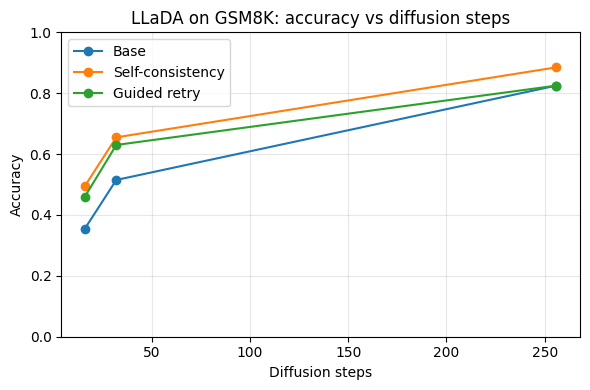

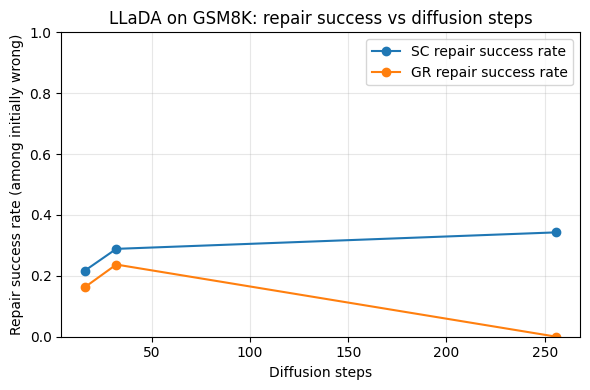

In [26]:
def plot_repairability_vs_steps(results_by_steps: Dict[int, Dict[str, float]]):
    steps = sorted(results_by_steps.keys())
    base_acc = [results_by_steps[s]["base_accuracy"] for s in steps]
    sc_acc = [results_by_steps[s]["sc_accuracy"] for s in steps]
    gr_acc = [results_by_steps[s]["gr_accuracy"] for s in steps]

    plt.figure(figsize=(6, 4))
    plt.plot(steps, base_acc, marker="o", label="Base")
    plt.plot(steps, sc_acc, marker="o", label="Self-consistency")
    plt.plot(steps, gr_acc, marker="o", label="Guided retry")
    plt.xlabel("Diffusion steps")
    plt.ylabel("Accuracy")
    plt.ylim(0.0, 1.0)
    plt.title("LLaDA on GSM8K: accuracy vs diffusion steps")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_repair_success_vs_steps(results_by_steps: Dict[int, Dict[str, float]]):
    steps = sorted(results_by_steps.keys())
    sc_rsr = [results_by_steps[s]["sc_repair_success_rate"] for s in steps]
    gr_rsr = [results_by_steps[s]["gr_repair_success_rate"] for s in steps]

    plt.figure(figsize=(6, 4))
    plt.plot(steps, sc_rsr, marker="o", label="SC repair success rate")
    plt.plot(steps, gr_rsr, marker="o", label="GR repair success rate")
    plt.xlabel("Diffusion steps")
    plt.ylabel("Repair success rate (among initially wrong)")
    plt.ylim(0.0, 1.0)
    plt.title("LLaDA on GSM8K: repair success vs diffusion steps")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_repairability_vs_steps(llada_diffusion_results_by_steps)
plot_repair_success_vs_steps(llada_diffusion_results_by_steps)

In [27]:
llada_diffusion_results_by_steps

{16: {'num_examples': 200,
  'base_accuracy': 0.355,
  'sc_accuracy': 0.495,
  'gr_accuracy': 0.46,
  'num_initially_incorrect': 129,
  'sc_repair_successes': 28,
  'gr_repair_successes': 21,
  'sc_repair_success_rate': 0.21705426356589147,
  'gr_repair_success_rate': 0.16279069767441862},
 32: {'num_examples': 200,
  'base_accuracy': 0.515,
  'sc_accuracy': 0.655,
  'gr_accuracy': 0.63,
  'num_initially_incorrect': 97,
  'sc_repair_successes': 28,
  'gr_repair_successes': 23,
  'sc_repair_success_rate': 0.28865979381443296,
  'gr_repair_success_rate': 0.23711340206185566},
 256: {'num_examples': 200,
  'base_accuracy': 0.825,
  'sc_accuracy': 0.885,
  'gr_accuracy': 0.825,
  'num_initially_incorrect': 35,
  'sc_repair_successes': 12,
  'gr_repair_successes': 0,
  'sc_repair_success_rate': 0.34285714285714286,
  'gr_repair_success_rate': 0.0}}

In [ ]:
llada_diffusion_results_by_steps_final = llada_diffusion_results_by_steps